## Sequential Flow

In [2]:
import os
from dotenv import load_dotenv
load_dotenv()

API_KEY = os.getenv('AZURE_OPENAI_API_KEY')
BASE_URL = os.getenv('OPENAI_BASE_URL')

os.environ['LANGCHAIN_API_KEY'] = os.getenv('LANGSMITH_API_KEY')
os.environ["LANGCHAIN_TRACING_V2"] = "true" # Enable LangSmith tracing
os.environ['LANGSMITH_PROJECT'] = 'LangGraphTraining' # Set the LangSmith project name

In [3]:
from langchain_openai import ChatOpenAI

model = ChatOpenAI(
    api_key= API_KEY,
    base_url = BASE_URL,
    model = 'gpt-5.1'
)

In [6]:
from typing import Dict, List, Optional, TypedDict
from langgraph.graph import END, START, StateGraph
from IPython.display import Image

In [7]:
class BMIState(TypedDict):

    weight_kg: float
    height_m: float
    bmi: float
    category: str

def label_bmi(state: BMIState) -> BMIState:
    bmi = state['bmi']
    if bmi < 18.5:
        state["category"] = "Underweight"
    elif 18.5 <= bmi < 25:
        state["category"] = "Normal"
    elif 25 <= bmi < 30:
        state["category"] = "Overweight"
    else:
        state["category"] = "Obese"

    return state

def calculate_bmi(state: BMIState) -> BMIState:
    weight = state['weight_kg']
    height = state['height_m']
    bmi = weight/(height**2)
    state['bmi'] = round(bmi, 2)
    return state

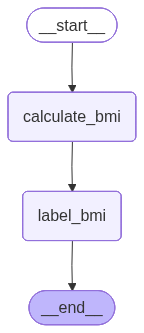

In [8]:
graph = StateGraph(BMIState)

# add nodes
graph.add_node("calculate_bmi", calculate_bmi) 
graph.add_node("label_bmi", label_bmi)

# add edges
graph.add_edge(START, "calculate_bmi")
graph.add_edge("calculate_bmi", "label_bmi")
graph.add_edge("label_bmi", END)
# compile
workflow = graph.compile()

Image(workflow.get_graph().draw_mermaid_png())

In [11]:
intial_state = {'weight_kg':76, 'height_m':1.78}
final_state = workflow.invoke(intial_state)
print(final_state)

{'weight_kg': 76, 'height_m': 1.78, 'bmi': 23.99, 'category': 'Normal'}


### Prompt Chainging

In [13]:
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser

parser = StrOutputParser()

In [ ]:
class BlogState(TypedDict):
    title: str
    outline: str
    content: str

def create_outline(state: BlogState) -> BlogState:
    topic = state['title']
    pt = PromptTemplate(template = 'Generate a outline in short for a blog on the topic {topic}')
    topic_chain = pt | model | parser

    state['outline'] = topic_chain.invoke(topic)
    return state

def create_blog(state: BlogState) -> BlogState:
    title = state['title']
    outline = state['outline']
    prompt = PromptTemplate(template = 'Write a detailed blog on the title - {title} using the follwing outline \n {outline}')
    content_chain = prompt | model | parser
    state['content'] = content_chain.invoke({'title': title, 'outline': outline})
    return state

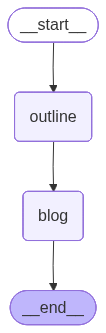

In [26]:
# Creatnig a Graph: 
graph = StateGraph(BlogState)
graph.add_node('outline', create_outline)
graph.add_node('blog', create_blog)

graph.add_edge(START, 'outline')
graph.add_edge('outline', 'blog')
graph.add_edge('blog', END)

workflow = graph.compile()
Image(workflow.get_graph().draw_mermaid_png())

In [27]:
initial_state = {'title': 'Atomic Lock in CPP'}
final_state = workflow.invoke(initial_state)

print(final_state['title'])
print("*"*50)
print(final_state['outline'])
print("*"*50)
print(final_state['content'])

Atomic Lock in CPP
**************************************************
Below is a structured, detailed outline you can use to write a blog post on “Atomic Lock in C++”. You can adjust depth or sections depending on your target audience (beginner vs. intermediate).

---

## 1. Introduction

1.1. What this post covers  
- Explain what “atomic lock” usually refers to in C++:  
  - Using `std::atomic` to implement lock-free or low-level locking mechanisms  
  - Contrast with higher-level synchronization like `std::mutex`  
- Why understanding atomic operations matters in concurrent programming

1.2. Who this article is for  
- C++ developers with basic knowledge of threads and `std::mutex`  
- Anyone curious about implementing or understanding lower-level synchronization primitives

1.3. Quick summary of key takeaways  
- What atomic operations are  
- How to implement a simple spinlock with `std::atomic_flag`  
- Trade-offs between atomic-based locks and `std::mutex`  
- Memory order and p

Also used the langchain components in the Graph